In [24]:
import pandas as pd
import numpy as np
import time
import os
import joblib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error, r2_score
from bayes_opt import BayesianOptimization

import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, Input
from keras.optimizers import Adagrad

In [15]:
#---------------------------
# 1. 데이터 불러오기 (태양광 모듈 데이터)
#---------------------------
# cp949 인코딩 적용 및 입력 5개, 출력 2개로 분리
data = pd.read_csv("240205_pvmodule_rawdata.csv", encoding='cp949')

X = data.iloc[:, 0:5].values
y = data.iloc[:, 5:7].values # 2 Outputs: [Displacement, Weight]

# 스케일링
scaler_X = RobustScaler()
scaler_y = RobustScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

In [31]:
joblib.dump(scaler_X, 'scaler_X_pvmodule.joblib')
joblib.dump(scaler_y, 'scaler_y_pvmodule.joblib')
print("✅ X, y 스케일러가 각각 성공적으로 분리 저장되었습니다.")

✅ X, y 스케일러가 각각 성공적으로 분리 저장되었습니다.


In [16]:
#---------------------------
# 2. ANN 모델 함수 (Multi-output 적용)
#---------------------------
def ANNmodel(num_layers, num_nodes, learning_rate, dropout_rate=0.0):
    model = Sequential()
    model.add(Input(shape=(X_scaled.shape[1],))) 

    for i in range(int(num_layers)):
        model.add(Dense(int(num_nodes), activation='tanh', kernel_initializer='glorot_normal'))
        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))

    # 출력층 노드 2개로 변경 (변위, 무게)
    model.add(Dense(2, kernel_initializer='glorot_normal')) 
    model.compile(optimizer=Adagrad(learning_rate=learning_rate), loss='mean_squared_error')
    return model

#---------------------------
# 3. Objective 함수 (K-Fold 기반)
#---------------------------
def objective(num_layers, num_nodes, learning_rate, dropout_rate, batch_size):
    kf = KFold(n_splits=10, shuffle=True, random_state=42)
    val_scores = []

    for train_idx, val_idx in kf.split(X_scaled):
        X_tr, X_val = X_scaled[train_idx], X_scaled[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]

        model = ANNmodel(num_layers, num_nodes, learning_rate, dropout_rate)
        model.fit(X_tr, y_tr, epochs=50, batch_size=int(batch_size), verbose=0)

        y_pred = model.predict(X_val, verbose=0)
        # 2개 출력에 대한 전체 MAPE 평균 계산
        val_scores.append(mean_absolute_percentage_error(y_val, y_pred))
    
    return -np.mean(val_scores)

In [17]:
#---------------------------
# 4. Bayesian Optimization 설정
#---------------------------
pbounds = {
    'num_layers': (2, 5),
    'num_nodes': (10, 100),
    'learning_rate': (0.001, 0.1),
    'dropout_rate': (0.1, 0.5),
    'batch_size': (4, 32)
}

start = time.time()

optimizer = BayesianOptimization(
    f=objective,
    pbounds=pbounds,
    random_state=42
)

# 초기 20회 랜덤 탐색 후 80회 최적화 -> 총 100번
optimizer.maximize(init_points=20, n_iter=80)

#---------------------------
# 5. 최적 하이퍼파라미터 출력 및 저장
#---------------------------
best_params = optimizer.max['params']
best_params['num_layers'] = int(best_params['num_layers'])
best_params['num_nodes'] = int(best_params['num_nodes'])
best_params['batch_size'] = int(best_params['batch_size'])

print("\n Best hyperparameters:")
for k, v in best_params.items():
    print(f"   {k}: {v}")

print(f"\n Elapsed time for BO: {time.time() - start:.2f} sec")

|   iter    |  target   | num_la... | num_nodes | learni... | dropou... | batch_... |
-------------------------------------------------------------------------------------
| 1         | -0.027662 | 3.1236203 | 95.564287 | 0.0734674 | 0.3394633 | 8.3685219 |
| 2         | -0.040005 | 2.4679835 | 15.227525 | 0.0867514 | 0.3404460 | 23.826032 |
| 3         | -0.031937 | 2.0617534 | 97.291886 | 0.0834118 | 0.1849356 | 9.0910990 |
| 4         | -0.018877 | 2.5502135 | 37.381801 | 0.0529508 | 0.2727780 | 12.154415 |
| 5         | -0.036598 | 3.8355586 | 22.554447 | 0.0299223 | 0.2465447 | 16.769959 |
| 6         | -0.039320 | 4.3555278 | 27.970640 | 0.0519092 | 0.3369658 | 5.3006115 |
| 7         | -0.078408 | 3.8226345 | 25.347171 | 0.0074401 | 0.4795542 | 31.037696 |
| 8         | -0.038163 | 4.4251920 | 37.415239 | 0.0106695 | 0.3736932 | 16.324269 |
| 9         | -0.032155 | 2.3661147 | 54.565921 | 0.0044044 | 0.4637281 | 11.245839 |
| 10        | -0.027064 | 3.9875668 | 38.053996 | 0.05

In [22]:
#---------------------------
# 6. MC Dropout 예측 함수
#---------------------------
def mc_dropout_predict(model, X, T=100):
    # (T, n_samples, 2)
    predictions = np.array([model(X, training=True) for _ in range(T)])
    return predictions.mean(axis=0), predictions.std(axis=0)

In [28]:
#---------------------------
# 7. Deep Ensemble 학습
#---------------------------
n_ensemble = 10
ensemble_preds = []
ensemble_std = []
ensemble_history = []

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.1, random_state=77)
os.makedirs('saved_models', exist_ok=True)

start_ens = time.time()
for i in range(n_ensemble):
    print(f"Training ensemble model {i+1}/{n_ensemble} ...")
    model = ANNmodel(best_params['num_layers'], best_params['num_nodes'],
                     best_params['learning_rate'], best_params['dropout_rate'])
    
    history = model.fit(X_train, y_train, epochs=200, batch_size=best_params['batch_size'],
                        validation_split=0.1, verbose=0)
    
    model.save(f'saved_models/pv_ensemble_model_{i+1}.keras')
    ensemble_history.append(history.history['loss'])

    mean_pred, std_pred = mc_dropout_predict(model, X_test)
    ensemble_preds.append(mean_pred) # (n_test, 2)
    ensemble_std.append(std_pred)    # (n_test, 2)

print(f"\n Elapsed time: {time.time() - start_ens:.2f} sec")

#---------------------------
# 8. 앙상블 평균 및 표준편차 계산 (스케일링된 상태)
#---------------------------
ensemble_preds = np.stack(ensemble_preds, axis=0) # (10, n_test, 2)
ensemble_std = np.stack(ensemble_std, axis=0)     # (10, n_test, 2)

y_pred_mean = np.mean(ensemble_preds, axis=0) # (n_test, 2)
y_pred_std = np.mean(ensemble_std, axis=0)    # (n_test, 2)

# 평가 지표 계산 전, 원래 물리 척도(mm, kg)로 역변환
y_test_original = scaler_y.inverse_transform(y_test) # 검증용 실제값 복원
y_pred_mean_original = scaler_y.inverse_transform(y_pred_mean) # 예측 평균값 복원

# 표준편차(std) 역변환: RobustScaler의 scale_ 값을 곱해줍니다.
y_pred_std_original = y_pred_std * scaler_y.scale_
# ==========================================

Training ensemble model 1/10 ...
Training ensemble model 2/10 ...
Training ensemble model 3/10 ...
Training ensemble model 4/10 ...
Training ensemble model 5/10 ...
Training ensemble model 6/10 ...
Training ensemble model 7/10 ...
Training ensemble model 8/10 ...
Training ensemble model 9/10 ...
Training ensemble model 10/10 ...

 Elapsed time: 422.34 sec



=== [Displacement] Metrics ===
R2: 0.9495
MAE: 0.0228
RMSE: 0.0301
MAPE: 0.0014
PICP: 1.0000
MPIW: 0.9652
CWC: 7.4687


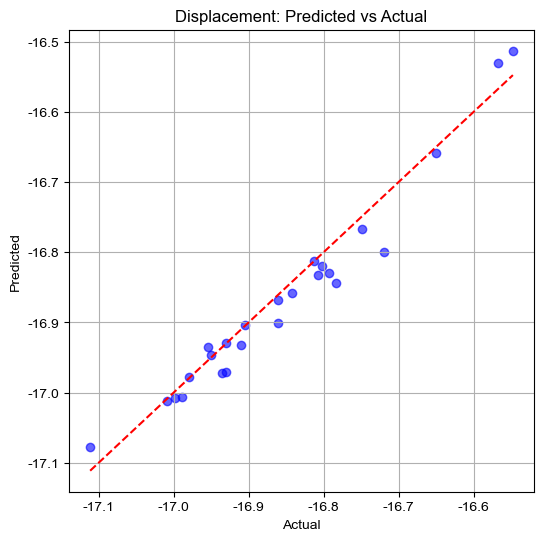

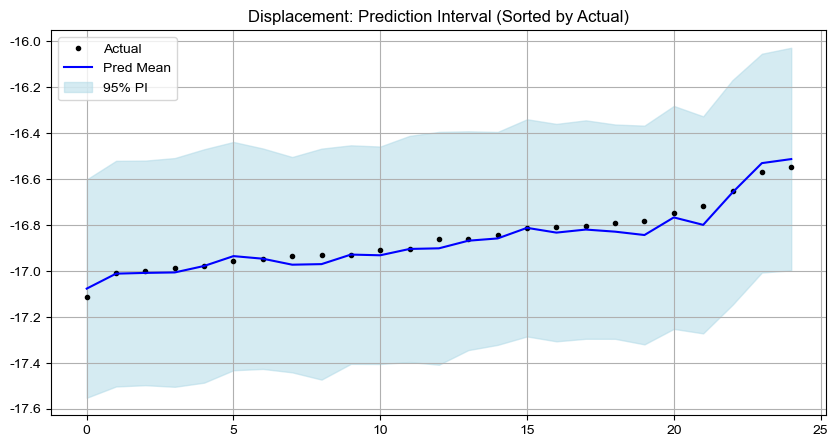


=== [Weight] Metrics ===
R2: 0.9796
MAE: 0.0067
RMSE: 0.0091
MAPE: 0.0013
PICP: 1.0000
MPIW: 0.2030
CWC: 1.5711


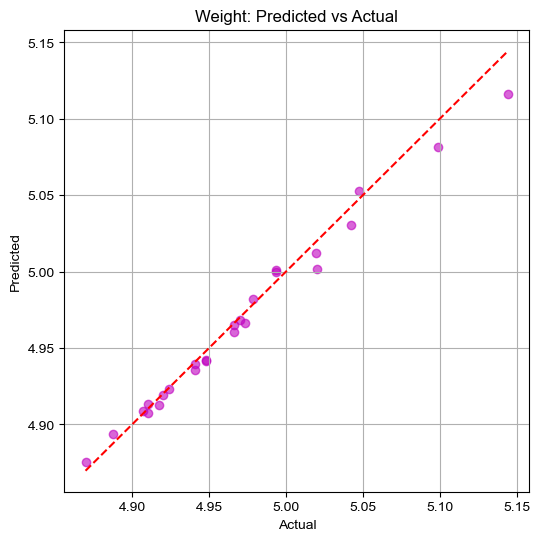

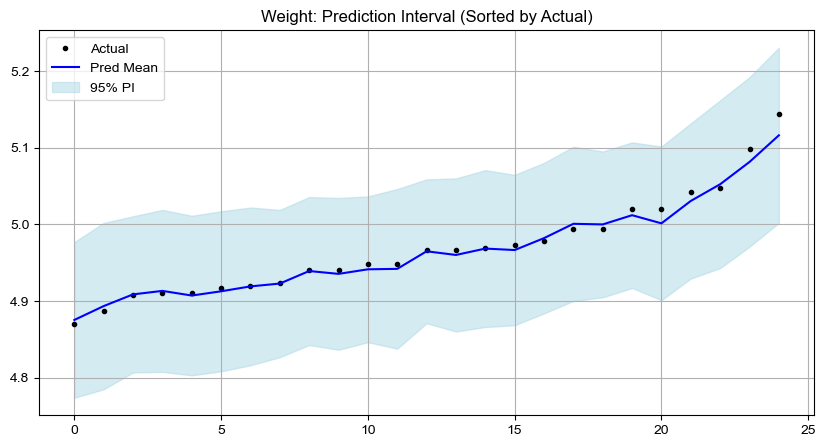


All predictions saved to predictions_pvmodule.csv


In [29]:
#---------------------------
# 9. 평가 지표 계산 및 결과 저장 (타겟별 분리)
#---------------------------
target_names = ['Displacement', 'Weight']
alpha = 0.05
gamma = 1000

# 원본 X값 복구 (결과 저장용)
X_test_original = scaler_X.inverse_transform(X_test)
df_pred = pd.DataFrame(X_test_original, columns=[f'X_{i+1}' for i in range(5)])

for col_idx, target in enumerate(target_names):
    # 역변환된(_original) 데이터를 사용하여 지표 계산
    y_test_col = y_test_original[:, col_idx]
    y_pred_mean_col = y_pred_mean_original[:, col_idx]
    y_pred_std_col = y_pred_std_original[:, col_idx]
    
    lower = y_pred_mean_col - 1.96 * y_pred_std_col
    upper = y_pred_mean_col + 1.96 * y_pred_std_col
    
    picp = np.mean((y_test_col >= lower) & (y_test_col <= upper))
    mpiw = np.mean(upper - lower)
    cwc = mpiw * (1 + gamma * np.exp(-100 * (picp - (1 - alpha))))
    
    metrics = {
        'Target': target,
        'R2': r2_score(y_test_col, y_pred_mean_col),
        'MAE': mean_absolute_error(y_test_col, y_pred_mean_col),
        'RMSE': np.sqrt(mean_squared_error(y_test_col, y_pred_mean_col)),
        'MAPE': mean_absolute_percentage_error(y_test_col, y_pred_mean_col),
        'PICP': picp, 'MPIW': mpiw, 'CWC': cwc
    }
    
    print(f"\n=== [{target}] Metrics ===")
    for k, v in metrics.items():
        if k != 'Target': print(f"{k}: {v:.4f}")
        
    # 예측 데이터프레임에 추가
    df_pred[f'{target}_true'] = y_test_col
    df_pred[f'{target}_pred'] = y_pred_mean_col
    df_pred[f'{target}_std'] = y_pred_std_col
    
    # ---------------------------
    # 10. 타겟별 시각화 저장
    # ---------------------------
    # Plot 1: Predicted vs Actual
    plt.figure(figsize=(6,6))
    plt.scatter(y_test_col, y_pred_mean_col, alpha=0.6, c='b' if col_idx==0 else 'm')
    plt.plot([y_test_col.min(), y_test_col.max()], [y_test_col.min(), y_test_col.max()], 'r--')
    plt.title(f'{target}: Predicted vs Actual')
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.grid(True)
    plt.savefig(f'predicted_vs_actual_{target}.png')
    plt.show()

    # Plot 2: Prediction Interval
    plt.figure(figsize=(10,5))
    idx = np.argsort(y_test_col) 
    plt.plot(range(len(idx)), y_test_col[idx], 'ko', markersize=3, label='Actual')
    plt.plot(range(len(idx)), y_pred_mean_col[idx], 'b-', label='Pred Mean')
    plt.fill_between(range(len(idx)), lower[idx], upper[idx], color='lightblue', alpha=0.5, label='95% PI')
    plt.title(f'{target}: Prediction Interval (Sorted by Actual)')
    plt.legend()
    plt.grid(True)
    plt.savefig(f'prediction_interval_{target}.png')
    plt.show()

# 최종 예측값 CSV 저장
df_pred.to_csv('predictions_pvmodule.csv', index=False)
print("\nAll predictions saved to predictions_pvmodule.csv")

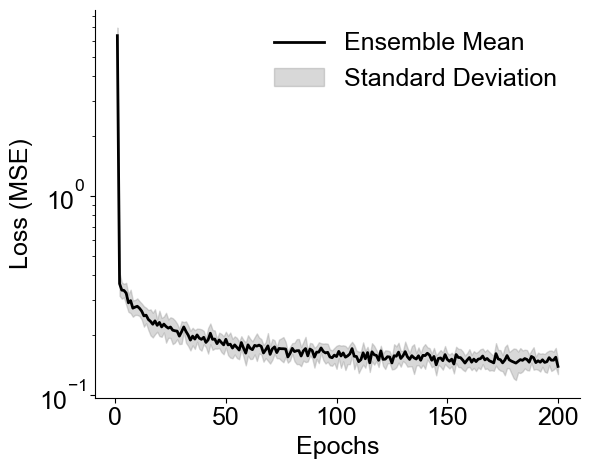

In [54]:
# -------------------------------------------------------
# 11. Ensemble Loss 시각화
# -------------------------------------------------------
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.unicode_minus'] = False
target_font_size = 18

# 학습 과정에서 저장된 ensemble_history를 DataFrame으로 변환
df_loss = pd.DataFrame(ensemble_history).T
epochs = range(1, len(df_loss) + 1)
loss_mean = df_loss.mean(axis=1)
loss_std = df_loss.std(axis=1)

fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(epochs, loss_mean, color='black', lw=2, label='Ensemble Mean')
ax.fill_between(epochs, loss_mean - loss_std, loss_mean + loss_std, 
                color='gray', alpha=0.3, label='Standard Deviation')

ax.set_yscale('log') 
ax.xaxis.set_major_locator(ticker.MultipleLocator(50)) 

ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_box_aspect(0.8)

ax.set_xlabel('Epochs', fontsize=target_font_size, fontweight='normal')
ax.set_ylabel('Loss (MSE)', fontsize=target_font_size, fontweight='normal')
ax.tick_params(axis='both', which='major', labelsize=target_font_size)
ax.legend(frameon=False, fontsize=target_font_size)

plt.tight_layout()
plt.savefig('ensemble_loss_pvmodule.png', dpi=300, bbox_inches='tight')
plt.show()

In [41]:
from tensorflow.keras.models import load_model
# -------------------------------------------------------------
# [수정] Train Set 예측 및 Test 데이터와 동일한 역변환 적용
# -------------------------------------------------------------
print("그래프 출력을 위해 Train Set 예측을 수행합니다...")
ensemble_preds_train = []
for i in range(n_ensemble):
    # 7번에서 저장한 앙상블 모델 불러오기
    loaded_model = load_model(f'saved_models/pv_ensemble_model_{i+1}.keras')
    mean_pred_train, _ = mc_dropout_predict(loaded_model, X_train)
    ensemble_preds_train.append(mean_pred_train)

ensemble_preds_train = np.stack(ensemble_preds_train, axis=0)
y_pred_train_mean = np.mean(ensemble_preds_train, axis=0)

# ★ 여기가 수정되었습니다 ★
# 기존 8번 코드에서 Test 데이터에 inverse_transform을 적용했으므로,
# Train 데이터(실제값, 예측값)에도 똑같이 적용해야 두 그룹의 좌표(스케일)가 일치합니다.
y_train_original = scaler_y.inverse_transform(y_train) 
y_pred_train_mean_original = scaler_y.inverse_transform(y_pred_train_mean)

그래프 출력을 위해 Train Set 예측을 수행합니다...



=== [Displacement] Metrics ===
R2: 0.9495
MAE: 0.0228
RMSE: 0.0301
MAPE: 0.0014
PICP: 1.0000
MPIW: 0.9652
CWC: 7.4687


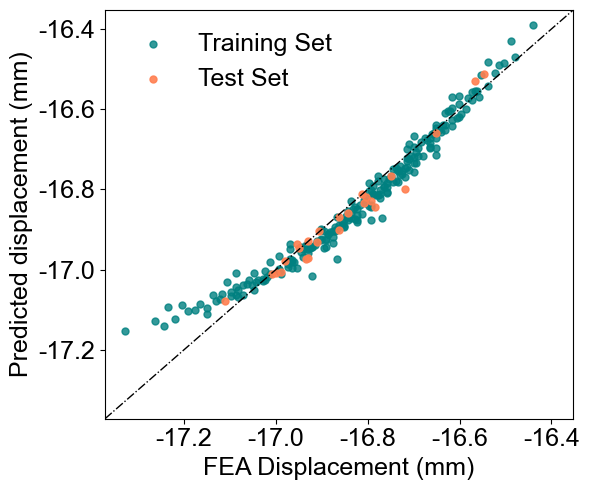


=== [Weight] Metrics ===
R2: 0.9796
MAE: 0.0067
RMSE: 0.0091
MAPE: 0.0013
PICP: 1.0000
MPIW: 0.2030
CWC: 1.5711


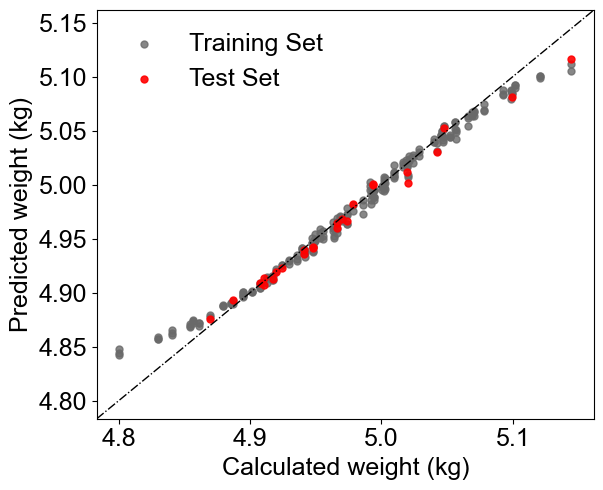


All predictions saved to predictions_pvmodule.csv


In [58]:
# --- 시각화 글씨체 Arial 설정 ---
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

target_font_size = 18
# -----------------------------------

# 9 & 10. 평가 지표 계산 및 논문 형식 시각화
#---------------------------
target_names = ['Displacement', 'Weight']
alpha = 0.05
gamma = 1000

# 원본 X값 복구 (결과 저장용)
X_test_original = scaler_X.inverse_transform(X_test)
df_pred = pd.DataFrame(X_test_original, columns=[f'X_{i+1}' for i in range(5)])

for col_idx, target in enumerate(target_names):
    
    # 데이터 추출
    y_test_col = y_test_original[:, col_idx]
    y_pred_mean_col = y_pred_mean_original[:, col_idx]
    y_pred_std_col = y_pred_std_original[:, col_idx]
    
    y_train_col = y_train_original[:, col_idx]
    y_pred_train_mean_col = y_pred_train_mean_original[:, col_idx]

    # Test 구간 및 평가지표 계산
    lower = y_pred_mean_col - 1.96 * y_pred_std_col
    upper = y_pred_mean_col + 1.96 * y_pred_std_col
    
    picp = np.mean((y_test_col >= lower) & (y_test_col <= upper))
    mpiw = np.mean(upper - lower)
    cwc = mpiw * (1 + gamma * np.exp(-100 * (picp - (1 - alpha))))
    
    metrics = {
        'Target': target,
        'R2': r2_score(y_test_col, y_pred_mean_col),
        'MAE': mean_absolute_error(y_test_col, y_pred_mean_col),
        'RMSE': np.sqrt(mean_squared_error(y_test_col, y_pred_mean_col)),
        'MAPE': mean_absolute_percentage_error(y_test_col, y_pred_mean_col),
        'PICP': picp, 'MPIW': mpiw, 'CWC': cwc
    }
    
    # Train 평가지표 (그래프 삽입용)
    train_mape = mean_absolute_percentage_error(y_train_col, y_pred_train_mean_col)
    train_r2 = r2_score(y_train_col, y_pred_train_mean_col)
    
    print(f"\n=== [{target}] Metrics ===")
    for k, v in metrics.items():
        if k != 'Target': print(f"{k}: {v:.4f}")
        
    # 결과 데이터프레임 저장
    df_pred[f'{target}_true'] = y_test_col
    df_pred[f'{target}_pred'] = y_pred_mean_col
    df_pred[f'{target}_std'] = y_pred_std_col
    
    # -----------------------------------
    # Plot 1: 논문 스타일 Predicted vs Actual
    # -----------------------------------
    fig, ax = plt.subplots(figsize=(6, 5))
    
    if target == 'Displacement':
        # Train(회색), Test(빨간색)
        ax.scatter(y_train_col, y_pred_train_mean_col, c='#008080', alpha=0.8, s=25, label='Training Set')
        ax.scatter(y_test_col, y_pred_mean_col, c='#ff7f50', alpha=0.9, s=25, label='Test Set')
        ax.set_xlabel('FEA Displacement (mm)', fontsize=target_font_size)
        ax.set_ylabel('Predicted displacement (mm)', fontsize=target_font_size)
        
    elif target == 'Weight':
        # Train(초록색), Test(빨간색)
        ax.scatter(y_train_col, y_pred_train_mean_col, c='dimgrey', alpha=0.8, s=25, label='Training Set')
        ax.scatter(y_test_col, y_pred_mean_col, c='red', alpha=0.9, s=25, label='Test Set')
        ax.set_xlabel('Calculated weight (kg)', fontsize=target_font_size)
        ax.set_ylabel('Predicted weight (kg)', fontsize=target_font_size)

    # 기준선 (y=x) 추가 (검은색 일점쇄선 '-.')
    min_val = min(ax.get_xlim()[0], ax.get_ylim()[0])
    max_val = max(ax.get_xlim()[1], ax.get_ylim()[1])
    ax.plot([min_val, max_val], [min_val, max_val], 'k-.', linewidth=1)
    
    # 그래프 축 범위 정방형 맞춤
    ax.set_xlim([min_val, max_val])
    ax.set_ylim([min_val, max_val])

    # ★ 추가된 부분: x축, y축 숫자(눈금) 크기 조절 ★
    # labelsize 숫자를 원하시는 크기(예: 10, 11, 12 등)로 변경하시면 됩니다.
    ax.tick_params(axis='both', which='major', labelsize=target_font_size)

    # 범례 테두리 제거
    ax.legend(loc='upper left', frameon=False, fontsize=target_font_size)
    
    plt.tight_layout()
    plt.savefig(f'predicted_vs_actual_{target}_f.png', dpi=300)
    plt.show()

# 최종 예측값 CSV 저장
df_pred.to_csv('predictions_pvmodule.csv', index=False)
print("\nAll predictions saved to predictions_pvmodule.csv")